# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [2]:
# Replace None with your code
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('data.sqlite')

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.
*Hint*: Make sure creditLimit is numeric.

In [3]:
# Replace None with your code
califonia_query = """
SELECT customerNumber, customerName, creditLimit
FROM customers
WHERE state = 'CA' AND CAST(creditLimit AS REAL) > 25000;
"""

california_customers = pd.read_sql_query(califonia_query, conn)

california_customers

,customerNumber,customerName,creditLimit
0,124,Mini Gifts Distributors Ltd.,210500.00
1,129,Mini Wheels Co.,64600.00
2,161,Technics Stores Inc.,84600.00
3,205,Toys4GrownUps.com,90700.00
4,239,Collectable Mini Designs Co.,105000.00
5,321,Corporate Gift Ideas Co.,105000.00
6,347,"Men 'R' US Retailers, Ltd.",57700.00
7,450,The Sharp Gifts Warehouse,77600.00
8,475,West Coast Collectables Co.,55400.00
9,487,Signal Collectibles Ltd.,60300.00


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [4]:
# Replace None with your code
international_collectable_query = """
SELECT customerNumber, customerName, country
FROM customers
WHERE TRIM(country) != 'USA' AND customerName LIKE '%Collect%';
"""

international_collectable_customers = pd.read_sql_query(international_collectable_query, conn)

international_collectable_customers

,customerNumber,customerName,country
0,114,"Australian Collectors, Co.",Australia
1,189,"Clover Collections, Co.",Ireland
2,201,"UK Collectables, Ltd.",UK
3,211,"King Kong Collectables, Co.",Hong Kong
4,227,Heintze Collectables,Denmark
5,260,"Royal Canadian Collectables, Ltd.",Canada
6,293,BG&E Collectables,Switzerland
7,353,Reims Collectables,France
8,376,Precious Collectables,Switzerland
9,382,Salzburg Collectables,Austria


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!
The WHERE clause above has 2 conditions that ensure filtering is being done correctly. 
* In the first condition;
    * TRIM() is used to ensure that any leading and trailing whitespaces are removed. This ensures if there are values like " USA" or "USA  ", they will be converted to "USA".
    * The country is then compared to the value "USA" and use the 'not equal to' operator (!=) to filter out all the records where the country is the US, ensuring all the remaining ones are non-US countries.
* In the second contition;
    * Any customer name containg "Collect" are found and kept. Any that do not are filtered out.
    * The like operator is used to search for the value "Collect". If it exists, the condion is met and if it doesn't exist, the condition is not met.
* The boolean operator 'AND' is used to ensure that the records that are kept satisfy both conditions. If one or both of those conditions is false, that entry is dropped.


### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [5]:
# Replace None with your code


# Only customers from the US.
# Filter out rows where state is empty
# Calculate average credit limit by state

credit_by_state_query = """
SELECT state, AVG(CAST(creditLimit AS REAL)) AS avg_credit_limit
FROM customers
WHERE TRIM(country) = 'USA' AND state != ''
GROUP BY state
ORDER BY avg_credit_limit DESC;
"""


state_credit_df = pd.read_sql_query(credit_by_state_query, conn)

state_credit_df

,state,avg_credit_limit
0,NH,114200.000000
1,NY,89966.666667
2,PA,84766.666667
3,CA,83854.545455
4,NV,71800.000000
5,MA,70755.555556
6,CT,57350.000000
7,NJ,43000.000000


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

C:\Users\Shaun Raymond\AppData\Local\Temp\ipykernel_10772\2623880494.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


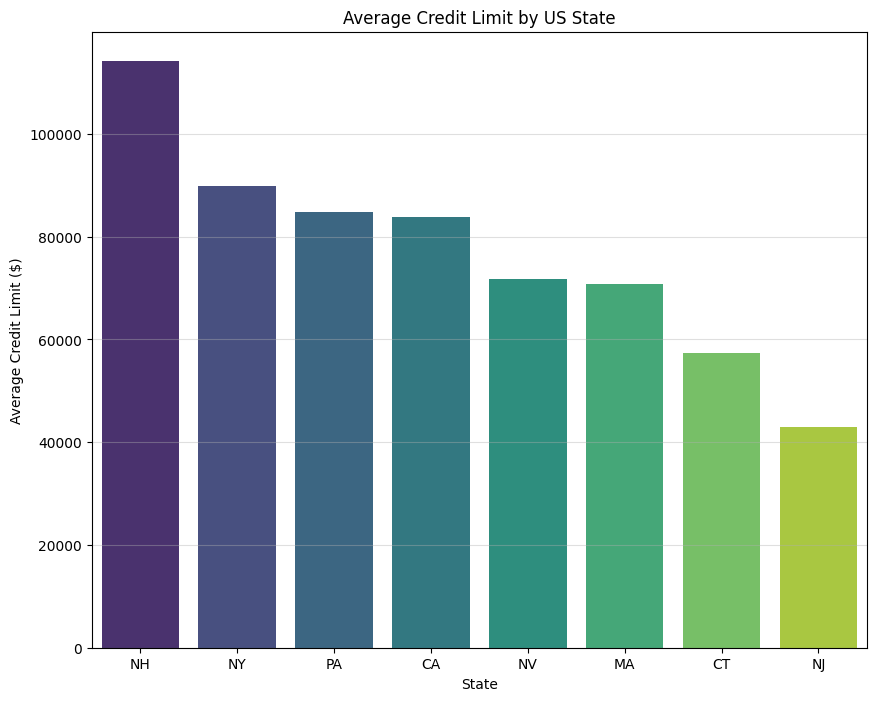

In [6]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state

# Since the data is the average of values grouped by categorical values, a bar chart is best.

plt.figure(figsize=(10, 8))
sns.barplot(
    data=state_credit_df, 
    x='state', 
    y='avg_credit_limit',
    palette='viridis'
)
plt.title('Average Credit Limit by US State')
plt.xlabel('State')
plt.ylabel('Average Credit Limit ($)')
plt.grid(axis='y', alpha=0.4)
plt.show() 

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [7]:
# Replace None with your code

# To ensure only customers who have made payments are included, an inner join is used to merge the 2 tables (customers and payments)

top_customers_query = """
SELECT c.customerNumber, c.customerName, SUM(CAST(p.amount AS REAL)) AS total_payments
FROM customers c
INNER JOIN payments p ON c.customerNumber = p.customerNumber
GROUP BY c.customerNumber, c.customerName
ORDER BY total_payments DESC
LIMIT 10;
"""

top_customers_df = pd.read_sql_query(top_customers_query, conn)

top_customers_df

,customerNumber,customerName,total_payments
0,141,Euro+ Shopping Channel,715738.98
1,124,Mini Gifts Distributors Ltd.,584188.24
2,114,"Australian Collectors, Co.",180585.07
3,151,Muscle Machine Inc,177913.95
4,148,"Dragon Souveniers, Ltd.",156251.03
5,323,"Down Under Souveniers, Inc",154622.08
6,187,"AV Stores, Co.",148410.09
7,276,"Anna's Decorations, Ltd",137034.22
8,321,Corporate Gift Ideas Co.,132340.78
9,146,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

C:\Users\Shaun Raymond\AppData\Local\Temp\ipykernel_10772\890075607.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


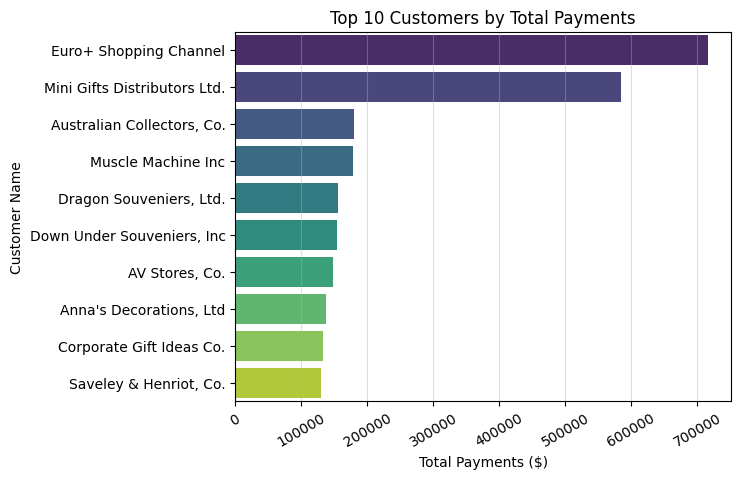

In [36]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments


sns.barplot(
    data=top_customers_df,
    x='total_payments',
    y='customerName',
    palette='viridis'
)
plt.title('Top 10 Customers by Total Payments')
plt.xlabel('Total Payments ($)')
plt.ylabel('Customer Name')
plt.xticks(rotation=30)
plt.grid(axis='x', alpha=0.4)
plt.show() 

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [9]:
# Replace None with you code

# Group by customer and product.
# Calculate sum of all units purchased by a customer for all orders
# Filter out the groups with less than 10. Must use HAVING since can't use WHERE.
# Sort in ascending order
# Join the tables with an inner join to ensure only customers who have placed orders and bought products are included.

customer_product_quantities_query = """
SELECT c.customerNumber, c.customerName, p.productCode, p.productName, 
    SUM(CAST(od.quantityOrdered AS REAL)) AS total_quantity
FROM customers c
INNER JOIN orders o ON c.customerNumber = o.customerNumber
INNER JOIN orderdetails od ON o.orderNumber = od.orderNumber
INNER JOIN products p ON od.productCode = p.productCode
GROUP BY c.customerNumber, c.customerName, p.productCode, p.productName
HAVING SUM(CAST(od.quantityOrdered AS REAL)) >= 10
ORDER BY total_quantity ASC;
"""

customer_product_quantities_df = pd.read_sql_query(customer_product_quantities_query, conn)

customer_product_quantities_df

,customerNumber,customerName,productCode,productName,total_quantity
0,314,Petit Auto,S18_2949,1913 Ford Model T Speedster,10.0
1,412,"Extreme Desk Decorations, Ltd",S24_4620,1961 Chevrolet Impala,10.0
2,119,La Rochelle Gifts,S32_2509,1954 Greyhound Scenicruiser,11.0
3,328,Tekni Collectables Inc.,S700_1691,American Airlines: B767-300,11.0
4,450,The Sharp Gifts Warehouse,S24_3191,1969 Chevrolet Camaro Z28,13.0
...,...,...,...,...,...
2526,141,Euro+ Shopping Channel,S24_3432,2002 Chevy Corvette,174.0
2527,141,Euro+ Shopping Channel,S12_4473,1957 Chevy Pickup,183.0
2528,141,Euro+ Shopping Channel,S24_1444,1970 Dodge Coronet,197.0
2529,141,Euro+ Shopping Channel,S24_2840,1958 Chevy Corvette Limited Edition,245.0


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [10]:
# Replace None with your code

product_line_analysis_query = """
SELECT pl.productLine, COUNT(DISTINCT p.productCode) AS number_of_products, 
    SUM(CAST(od.quantityOrdered AS REAL)) AS total_quantity_ordered
FROM productlines pl
INNER JOIN products p ON pl.productLine = p.productLine
LEFT JOIN orderdetails od ON p.productCode = od.productCode
GROUP BY pl.productLine
ORDER BY total_quantity_ordered DESC;
"""

product_line_analysis_df = pd.read_sql_query(product_line_analysis_query, conn)

product_line_analysis_df

,productLine,number_of_products,total_quantity_ordered
0,Classic Cars,38,35582.0
1,Vintage Cars,24,22933.0
2,Motorcycles,13,12778.0
3,Planes,12,11872.0
4,Trucks and Buses,11,11001.0
5,Ships,9,8532.0
6,Trains,3,2818.0


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

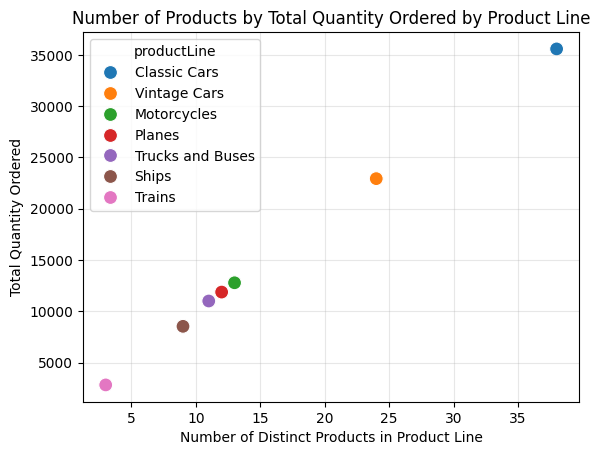

In [11]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered

sns.scatterplot(
    data=product_line_analysis_df,
    x='number_of_products',
    y='total_quantity_ordered',
    s=100,  # Marker size
    hue= "productLine"
)

plt.title('Number of Products by Total Quantity Ordered by Product Line')
plt.xlabel('Number of Distinct Products in Product Line')
plt.ylabel('Total Quantity Ordered')
plt.grid(alpha=0.3)
plt.show() 

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!
* Since the goal is to understand if there's a relationship between two numerical variables, ie how many products are in a product line and how many total units of those products have been ordered,a scatter plot is perfect since it shows each product line as a single point on the graph

* The visualization suggests that product lines with more products tend to have higher total orders.

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [12]:
# Replace None with your code

remote_offices_query = """
SELECT e.employeeNumber, e.firstName, e.lastName, e.jobTitle, e.reportsTo,
    s.firstName || ' ' || s.lastName AS supervisorName, e.officeCode, o.city, o.country
FROM employees e
INNER JOIN offices o ON e.officeCode = o.officeCode
LEFT JOIN employees s ON e.reportsTo = s.employeeNumber
WHERE e.officeCode IN (
    SELECT officeCode
    FROM employees
    GROUP BY officeCode
    HAVING COUNT(*) < 5
)
ORDER BY e.officeCode, e.employeeNumber;
"""

remote_offices_df = pd.read_sql_query(remote_offices_query, conn)

remote_offices_df

,employeeNumber,firstName,lastName,jobTitle,reportsTo,supervisorName,officeCode,city,country
0,1188,Julie,Firrelli,Sales Rep,1143,Anthony Bow,2,Boston,USA
1,1216,Steve,Patterson,Sales Rep,1143,Anthony Bow,2,Boston,USA
2,1286,Foon Yue,Tseng,Sales Rep,1143,Anthony Bow,3,NYC,USA
3,1323,George,Vanauf,Sales Rep,1143,Anthony Bow,3,NYC,USA
4,1621,Mami,Nishi,Sales Rep,1056,Mary Patterson,5,Tokyo,Japan
5,1625,Yoshimi,Kato,Sales Rep,1621,Mami Nishi,5,Tokyo,Japan
6,1088,William,Patterson,Sales Manager (APAC),1056,Mary Patterson,6,Sydney,Australia
7,1611,Andy,Fixter,Sales Rep,1088,William Patterson,6,Sydney,Australia
8,1612,Peter,Marsh,Sales Rep,1088,William Patterson,6,Sydney,Australia
9,1619,Tom,King,Sales Rep,1088,William Patterson,6,Sydney,Australia


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!
The subquery's purpose is to identify which offices have fewer than 5 employees. Structuring it that way ensures it works by;
* Grouping all employees by the office they work in.
* Counting how many emplooyes are in each office.
* Filtering out offices where the number of employees is greater than or equal to 5.

The main query uses the subquery to select only employees who work in one of those small offices.

LEFT JOIN employees s ON e.reportsTo = s.employeeNumber is used to include the supervisor's name. 
* A left join is used to avoid dropping records where the employee has no supervisors since upper management still needs to know about them. 

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [13]:
# Replace None with your code

conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [14]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

### Initial Exploration

<u>Total number of movies (2010–2019)<u>

In [15]:
total_movies_query = """
SELECT COUNT(*) AS total_movies
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019;
"""

total_movies_df = pd.read_sql_query(total_movies_query, conn4)
total_movies_df

,total_movies
0,145081


There were 145,081 total movies from the year 2010 to the year 2019.

<u>Movies per year (2010–2019)<u>

In [16]:
movies_by_year_query = """
SELECT start_year, COUNT(*) AS num_movies
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019
GROUP BY start_year
ORDER BY start_year;
"""

movies_by_year_df = pd.read_sql_query(movies_by_year_query, conn4)
movies_by_year_df

,start_year,num_movies
0,2010,11849
1,2011,12900
2,2012,13787
3,2013,14709
4,2014,15589
5,2015,16243
6,2016,17272
7,2017,17504
8,2018,16849
9,2019,8379


2019 had the least number of movies from the year 2010 to the year 2019.

<u>Top 10 most common genres<u>

In [17]:
top_genres_query = """
SELECT genres, COUNT(*) AS count
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019
    AND genres IS NOT NULL
    AND genres != ''
GROUP BY genres
ORDER BY count DESC
LIMIT 10;
"""

top_genres_df = pd.read_sql_query(top_genres_query, conn4)
top_genres_df

,genres,count
0,Documentary,32106
1,Drama,21306
2,Comedy,9096
3,Horror,4309
4,"Comedy,Drama",3497
5,Thriller,2984
6,Action,2164
7,"Biography,Documentary",2115
8,"Drama,Romance",2069
9,"Comedy,Drama,Romance",1554


The 3 most common genres are;
* Documentary.
* Drama.
* Comedy

<u>Summary statistics for average ratings<u>

In [18]:
# Query 4: 
ratings_stats_query = """
SELECT COUNT(*) AS total_rated_movies, AVG(averagerating) AS avg_rating, 
    MIN(averagerating) AS min_rating, MAX(averagerating) AS max_rating
FROM movie_ratings
WHERE averagerating IS NOT NULL;
"""

ratings_stats_df = pd.read_sql_query(ratings_stats_query, conn4)
ratings_stats_df

,total_rated_movies,avg_rating,min_rating,max_rating
0,73856,6.332729,1.0,10.0


<u>Count nulls in movie_basics columns

In [19]:
null_check_query = """
SELECT COUNT(*) AS total_movies,
    SUM(CASE WHEN runtime_minutes IS NULL THEN 1 ELSE 0 END) AS null_runtime,
    SUM(CASE WHEN genres IS NULL OR genres = '' THEN 1 ELSE 0 END) AS null_genres
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019;
"""

null_check_df = pd.read_sql_query(null_check_query, conn4)
null_check_df

,total_movies,null_runtime,null_genres
0,145081,30765,5359


<u>Ratings distribution – number of movies per rating bracket

In [20]:
rating_distribution_query = """
SELECT 
    CASE 
        WHEN averagerating < 3.0 THEN '1-2.9'
        WHEN averagerating < 5.0 THEN '3-4.9'
        WHEN averagerating < 7.0 THEN '5-6.9'
        WHEN averagerating < 9.0 THEN '7-8.9'
        ELSE '9-10'
    END AS rating_bracket,
    COUNT(*) AS num_movies
FROM movie_ratings
WHERE averagerating IS NOT NULL
GROUP BY rating_bracket
ORDER BY rating_bracket;
"""

rating_distribution_df = pd.read_sql_query(rating_distribution_query, conn4)
rating_distribution_df

,rating_bracket,num_movies
0,1-2.9,1734
1,3-4.9,10649
2,5-6.9,34566
3,7-8.9,25481
4,9-10,1426


The rating bracket 5-6.9 has the most numbers of movies while 9-10 has the least with 1-2.9 having a 308 more than 9-10

### Business Question
In the movie industry, it is debated whether or not larger creative teams improve quality. The employer is interested in finding out if movies with more directors or writers tend to have higher average ratings and more votes.

To answer this question, we need to calculate;
* Number of distinct directors per movie.
* Number of distinct writers per movie.
* Average rating per movie.
* Number of votes per movie.

Movies with null ratings and those without directors/writers will be excluded.

In [21]:
team_analysis_query = """
SELECT mb.movie_id, mb.primary_title, mr.averagerating, mr.numvotes,
    COUNT(DISTINCT d.person_id) AS num_directors,
    COUNT(DISTINCT w.person_id) AS num_writers
FROM movie_basics mb

INNER JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
INNER JOIN directors d ON mb.movie_id = d.movie_id
INNER JOIN writers w ON mb.movie_id = w.movie_id

WHERE mb.start_year BETWEEN 2010 AND 2019
  AND mr.averagerating IS NOT NULL
GROUP BY mb.movie_id, mb.primary_title, mr.averagerating, mr.numvotes
ORDER BY num_directors DESC, num_writers DESC;
"""
# Using an inner join ensures all records with missing values are filtered out.

team_analysis_df = pd.read_sql_query(team_analysis_query, conn4)
team_analysis_df.head()

,movie_id,primary_title,averagerating,numvotes,num_directors,num_writers
0,tt4050462,World of Death,7.2,31,83,46
1,tt3064438,Venice 70: Future Reloaded,5.9,216,73,5
2,tt2234076,"Milano 55,1. Cronaca di una settimana di passioni",5.9,8,63,2
3,tt4942694,60 Seconds to Die,5.7,66,61,33
4,tt3528906,Our RoboCop Remake,6.5,305,59,30


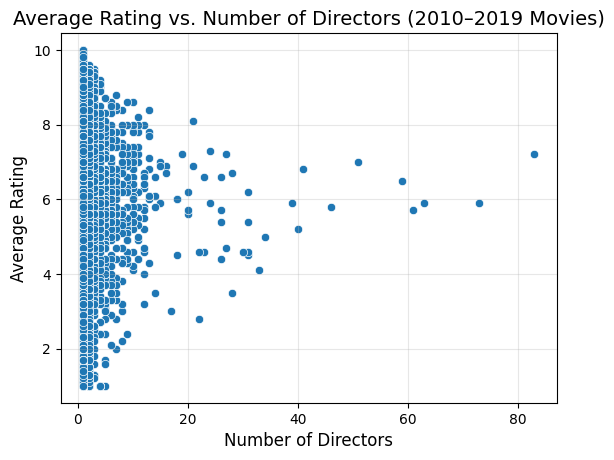

In [33]:
sns.scatterplot(
    data= team_analysis_df,
    x= 'num_directors',
    y= 'averagerating'
)
plt.title('Average Rating vs. Number of Directors (2010–2019 Movies)', fontsize=14)
plt.xlabel('Number of Directors', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

C:\Users\Shaun Raymond\AppData\Local\Temp\ipykernel_10772\3683851297.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


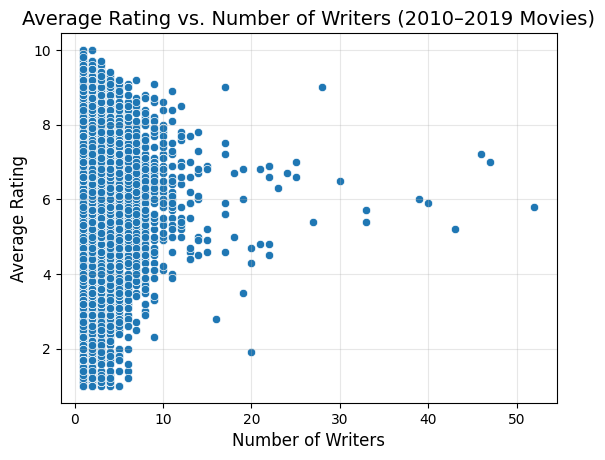

In [ ]:
sns.scatterplot(
    data=team_analysis_df,
    x='num_writers',
    y='averagerating'
)
plt.title('Average Rating vs. Number of Writers (2010–2019 Movies)', fontsize=14)
plt.xlabel('Number of Writers', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Neither scatterplot shows a clear relationship between team size (number of directors or writers) and average rating — ratings are spread fairly evenly across all team sizes. 

Therefore, it can be concluded that team size alone is not a strong predictor of audience rating.

Initially, the numvotes variable was used, making this multivariate analysis. However, it was only adding clutter to the visualizations without adding any insights, hence it was removed.

### Data cleaning.

* Missing runtime_minutes: 30,765 movies have null runtime values – exclude these rows from any runtime-based analysis.
* Missing genres: 5,359 movies have null or empty genres – exclude these rows when grouping or filtering by genre.
* Missing ratings: Only 73,856 out of 145,081 movies have ratings (51%) – use INNER JOIN with movie_ratings to automatically exclude unrated movies from rating-based analysis.
* Missing director/writer relationships: Some movies have no entries in directors or writers tables – use INNER JOIN to exclude these movies from team-size analysis, rather than imputing zeros.
* Duplicate entries in directors: A movie may have the same person listed multiple times – use COUNT(DISTINCT person_id) to count unique directors per movie.
* Duplicate entries in writers: Same issue as directors – use COUNT(DISTINCT person_id) to count unique writers per movie.
* Genre normalization: Genres are stored as pipe-separated strings (e.g., "Comedy|Drama|Romance") – for detailed genre analysis, split into separate rows or a normalized lookup table.
* Inconsistent casing in categorical columns: region and language fields may have inconsistent capitalization – standardize to consistent case (e.g., UPPER) for accurate grouping.
* Incomplete 2019 data: Only 8,379 movies appear in 2019 compared to ~17,000 in previous years – flag or exclude 2019 for year-over-year trend analysis.
* Data type awareness: runtime_minutes is stored as REAL; birth_year and death_year are REAL due to nulls – handle nulls appropriately and avoid casting to INTEGER when nulls exist.